Today's topics:
* comparisons
* boolean masks
* selecting rows with `.loc`
* integer positions with `.iloc`

# Which superconductors cross 77 K?

A superconductor operates below its critical temperature, $T_c$.
Liquid helium boils near 4.2 K, while liquid nitrogen boils near 77 K at atmospheric pressure.
Crossing 77 K does not make a material application-ready, but it changes the cooling problem substantially.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/Magnet_levitating_on_top_of_superconductor_cooled_by_liquid_nitrogen.jpg/960px-Magnet_levitating_on_top_of_superconductor_cooled_by_liquid_nitrogen.jpg" alt="A small magnet floating above a superconducting disc cooled by liquid nitrogen" width=520/>

Photo by Ainur physicist, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Magnet_levitating_on_top_of_superconductor_cooled_by_liquid_nitrogen.jpg).
Above: a magnet levitating over a superconductor cooled by liquid nitrogen, an example of the [Meissner effect](https://en.wikipedia.org/wiki/Meissner_effect).

Today we'll ask: *Which reported superconductors cross the liquid-nitrogen threshold?*

In [1]:
#@title Find the three-column superconductor table (click ▶ to run) { display-mode: "form" }
import os

_file = 'superconductors_l11.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (path for path in (
        f'datasets/{_file}',
        f'../datasets/{_file}',
        f'../../datasets/{_file}',
        f'../../../datasets/{_file}',
    ) if os.path.exists(path)),
    None,
)
source = _local if _local else _github

print(f'Ready to read {_file}')

Ready to read superconductors_l11.csv


## The table

This course table comes from [Hamidieh's superconductivity dataset](https://archive.ics.uci.edu/dataset/464/superconductivty+data), which was derived from the NIMS SuperCon database.
Each row contains a chemical formula, the number of elements in the formula and a reported critical temperature.

In [2]:
import pandas as pd

data = pd.read_csv(source)
display(data.head())

,material,number_of_elements,critical_temp
0,Ba0.2La1.8Cu1O4,4,29.0
1,Ba0.1La1.9Ag0.1Cu0.9O4,5,26.0
2,Ba0.1La1.9Cu1O4,4,19.0
3,Ba0.15La1.85Cu1O4,4,22.0
4,Ba0.3La1.7Cu1O4,4,23.0


In [3]:
print(data.shape)

(21263, 3)


The 21,263 records contain 15,542 unique formula strings.
A row is a reported record, not necessarily a unique material.

# One row by position: `.iloc`

`.iloc` selects by integer position.
Position 0 is the first row.

In [4]:
first_record = data.iloc[0]
display(first_record)

material              Ba0.2La1.8Cu1O4
number_of_elements                  4
critical_temp                    29.0
Name: 0, dtype: object

# Comparing one value

A comparison returns a `bool`: either `True` or `False`.

In [5]:
first_tc = first_record['critical_temp']

print(first_tc)
print(first_tc > 77)

29.0
False


The six comparison operators are `>`, `<`, `>=`, `<=`, `==` and `!=`.
A single `=` assigns a value; `==` compares two values.

In [6]:
print(first_tc == 29.0)
print(first_tc != 29.0)
print(first_tc >= 29.0)

True
False
True


# Comparing a whole column

The same comparison works on a `Series`.

In [7]:
critical_temp = data['critical_temp']
above_nitrogen = critical_temp > 77

display(above_nitrogen.head())
print(len(above_nitrogen))

0    False
1    False
2    False
3    False
4    False
Name: critical_temp, dtype: bool

21263


The result is a Boolean `Series` with one answer for every row.
We call it a **mask** because it can select the rows where the condition is `True`.

## Count and fraction

`True` counts as 1 and `False` counts as 0.

In [8]:
import numpy as np

print(np.sum(above_nitrogen))
print(np.mean(above_nitrogen))

3895
0.1831820533320792


There are 3,895 records above 77 K, or 18.3% of this table.

# Selecting rows with `.loc`

Put the mask inside `.loc` to retain the matching rows.

In [9]:
nitrogen_records = data.loc[above_nitrogen]

display(nitrogen_records.head())
print(nitrogen_records.shape)

,material,number_of_elements,critical_temp
16,Y1Ba1.5Ca0.5Cu3O7,5,82.0
30,Yb6Ba1Cu1O,4,78.6
31,Yb1.62La0.18Ba0.18Sr0.02Cu1O,6,79.3
32,Y0.4Ba0.6Cu1O,4,90.0
33,Y0.4Ba0.6Cu1O,4,90.5


(3895, 3)


`.loc` also accepts a column selection after a comma.

In [10]:
columns = ['material', 'critical_temp']
display(data.loc[above_nitrogen, columns].head())

,material,critical_temp
16,Y1Ba1.5Ca0.5Cu3O7,82.0
30,Yb6Ba1Cu1O,78.6
31,Yb1.62La0.18Ba0.18Sr0.02Cu1O,79.3
32,Y0.4Ba0.6Cu1O,90.0
33,Y0.4Ba0.6Cu1O,90.5


The pattern is `data.loc[rows, columns]`.
Before the comma we specify which rows to retain; after it we specify which columns to display.

The selected rows keep their original index labels.
Use `.iloc[0]` for the first position in the smaller table.

In [11]:
display(nitrogen_records.iloc[0])

material              Y1Ba1.5Ca0.5Cu3O7
number_of_elements                    5
critical_temp                      82.0
Name: 16, dtype: object

### [Check your understanding]

1. Build a mask called `below_helium` for records with `critical_temp` below 4.2 K.
2. Use `np.sum` and `np.mean` to report the count and fraction.
3. Select the matching rows with `.loc`.
4. Display only the `material` and `critical_temp` columns.

# Describing the selected population

Statistics and plots now describe the selected records.

In [12]:
print(f"median of all records:       {np.median(data['critical_temp']):.1f} K")
print(f"median above 77 K:           {np.median(nitrogen_records['critical_temp']):.1f} K")

median of all records:       20.0 K
median above 77 K:           90.0 K


The second median describes only the records that passed the 77 K screen.

Text(0, 0.5, 'number of records')

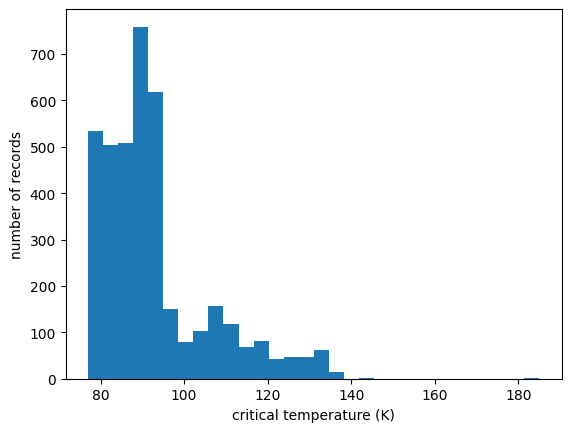

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist(nitrogen_records['critical_temp'], bins=30)
ax.set_xlabel('critical temperature (K)')
ax.set_ylabel('number of records')

Most of the selected records lie between 77 and 100 K, with fewer records at higher temperatures.
This is a distribution of records in a literature-derived database, not a distribution of all possible superconductors.

# Combining conditions

`&` combines masks with **and**, so both conditions must be `True`.
Each comparison needs its own parentheses.

In [14]:
simple_and_warm = (
    (data['critical_temp'] > 77)
    & (data['number_of_elements'] <= 4)
)

print(np.sum(simple_and_warm))

997


In [15]:
display(data.loc[
    simple_and_warm,
    ['material', 'number_of_elements', 'critical_temp'],
].head())

,material,number_of_elements,critical_temp
30,Yb6Ba1Cu1O,4,78.6
32,Y0.4Ba0.6Cu1O,4,90.0
33,Y0.4Ba0.6Cu1O,4,90.5
34,Er0.5Ba0.5Cu1O,4,92.0
35,Tm0.35Ba0.65Cu1O,4,93.2


> Note: `data['critical_temp'] > 77 & data['number_of_elements'] <= 4` has the wrong order of operations.
> Put parentheses around each comparison before combining the masks.

### [Check your understanding]

1. Build a mask called `high_and_complex` for records with `critical_temp` above 100 K **and** `number_of_elements` at least 5.
2. Count the matching records.
3. Select and display the `material`, `number_of_elements` and `critical_temp` columns.
4. Plot a histogram of their critical temperatures, with both axes labeled.

## Either condition: `|`

`|` combines masks with **or**, so either condition can be `True`.

In [16]:
very_warm_or_complex = (
    (data['critical_temp'] > 100)
    | (data['number_of_elements'] >= 5)
)

print(np.sum(very_warm_or_complex))

9337


# Repeated formulas

Use `==` to select every record with the same formula.

In [17]:
same_formula = data['material'] == 'Bi1Sr1Ca1Cu2O'

display(data.loc[
    same_formula,
    ['material', 'number_of_elements', 'critical_temp'],
])

,material,number_of_elements,critical_temp
199,Bi1Sr1Ca1Cu2O,5,110.0
202,Bi1Sr1Ca1Cu2O,5,106.0
247,Bi1Sr1Ca1Cu2O,5,105.0
619,Bi1Sr1Ca1Cu2O,5,80.0


These records report different critical temperatures for the same formula.
Processing, pressure and other experimental conditions are not represented adequately by these three columns.

# Summary

* A comparison returns `True` or `False`.
* Comparing a `Series` returns one Boolean value per row.
* `np.sum(mask)` counts matches, and `np.mean(mask)` gives their fraction.
* `.loc[mask]` selects rows by a Boolean condition.
* `.loc[rows, columns]` selects both dimensions, while `.iloc` selects by integer position.
* `&` and `|` combine masks; each comparison needs parentheses.

In this table, 3,895 reported records cross 77 K.
That threshold defines a useful population for further study, but it does not establish application performance.

## Further reading

* VanderPlas, *Python Data Science Handbook*, [Comparisons, Masks, and Boolean Logic](https://jakevdp.github.io/PythonDataScienceHandbook/02.06-boolean-arrays-and-masks.html)
* [Hamidieh superconductivity dataset](https://archive.ics.uci.edu/dataset/464/superconductivty+data), UCI Machine Learning Repository (CC BY 4.0)
* Hamidieh, [*A data-driven statistical model for predicting the critical temperature of a superconductor*](https://doi.org/10.1016/j.commatsci.2018.07.052), *Computational Materials Science* 154, 346–354 (2018)